## CZESC PIERWSZA

### Instalacja pakietow

Zdecydowalismy sie na pobranie takich o to pakietow:  
- `tidyverse` - do wizualizacji
- `janitor`- pomocne przy porzadkowaniu nazw kolumn
- `skimr`- podsumowanie odnosnie statystyk

In [2]:
install.packages(c("tidyverse", "janitor", "skimr"))

library(tidyverse)
library(janitor) 
library(skimr) 

install.packages("here")
library(here)

install.packages("patchwork")
library(patchwork)



Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.0.4     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Dolaczanie pakietu: 'janitor'


Nastepujace obiekty zostaly zakryte z 'package:stats':

    chisq.test, fisher.test





Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


here() starts at /Users/michaelbak/Desktop




Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


### Wczytanie danych

`clean_names()` sprzata nazwy kolumn, czyli spacje zamienia na podkreslenia, wielkie litery na male ***(Central AAir --> central_air)***.  
  
`glimpse()` sluzy do poweidzmy kolokwialnie *'rzucenia okiem'* na dane.

In [6]:
ames_raw <-read_csv(here("UNIVERSITY", "AmesHousing.csv")) |> clean_names()
glimpse(ames_raw)

Rows: 2930 Columns: 82
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (45): PID, MS SubClass, MS Zoning, Street, Alley, Lot Shape, Land Contou...
dbl (37): Order, Lot Frontage, Lot Area, Overall Qual, Overall Cond, Year Bu...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00C4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00D6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00DC>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00E4>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00F6>' to native encoding"
Warning message in FUN(X[[i]], ...):
"unable to translate '<U+00FC>' to native encoding"
Warning message in FUN(X[[i]], .

Rows: 2,930
Columns: 82
$ order           <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,~
$ pid             <chr> "0526301100", "0526350040", "0526351010", "0526353030"~
$ ms_sub_class    <chr> "020", "020", "020", "020", "060", "060", "120", "120"~
$ ms_zoning       <chr> "RL", "RH", "RL", "RL", "RL", "RL", "RL", "RL", "RL", ~
$ lot_frontage    <dbl> 141, 80, 81, 93, 74, 78, 41, 43, 39, 60, 75, NA, 63, 8~
$ lot_area        <dbl> 31770, 11622, 14267, 11160, 13830, 9978, 4920, 5005, 5~
$ street          <chr> "Pave", "Pave", "Pave", "Pave", "Pave", "Pave", "Pave"~
$ alley           <chr> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA~
$ lot_shape       <chr> "IR1", "Reg", "IR1", "Reg", "IR1", "IR1", "Reg", "IR1"~
$ land_contour    <chr> "Lvl", "Lvl", "Lvl", "Lvl", "Lvl", "Lvl", "Lvl", "HLS"~
$ utilities       <chr> "AllPub", "AllPub", "AllPub", "AllPub", "AllPub", "All~
$ lot_config      <chr> "Corner", "Inside", "Corner", "Corner", "Inside", "Ins~
$ land_slope    

Jak widac dane zostaly wczytane.  
Widzimy tutaj podsumwoanie danych..  
- 2930 obserwacji
- 82 kolumny
- 45 zmienncyh znakowcyh
- 37 zmiennych liczbowych
- nazwy kolumn zostaly zmienione na snake case

### Opis zbioru danych

Zdecydowaliśmy sie na **Ames Housing Dataset** jako nasz unikalny zbiór danych.  
Zbiór danych pochodzi z Kaggle [Ames Data Set](https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset).  

- **Liczba obserwacji:** 2 930  
- **Liczba cech:** 79  
- **Cechy:** różnorodne atrybuty opisujące domy  
- **Zmienna docelowa:** `SalePrice` (cena sprzedaży domu w USD)  

Opis zbioru danych na Kaggle:
> _“The Ames Housing Dataset is widely used in the machine learning community for tasks such as regression modeling, feature engineering, and predictive analytics related to housing prices. It serves as a valuable resource for developing and testing machine learning algorithms and techniques in the real estate domain.”_    

Podsumowujac, z tychze 79 cech wybralismy:
- ogolne 14 cech
    - 7 cech dyskretnych  
    - 7 cech ciągłych


Dzięki wybraniu 7 zmiennych dyskretnych i 7 zmiennych ciągłych, uzyskujemy zrównoważony zestaw danych idealny do dalszej analizy statystycznej.


### Podzbior danych & opis

Nastepnie budujemy podzbior z naszych 14 wybranych cech.  

In [7]:
sel_vars <- c("central_air", "paved_drive", "bsmt_full_bath", "kitchen_abv_gr", "fireplaces", "bsmt_half_bath","garage_cars", "lot_area", "gr_liv_area", "total_bsmt_sf", "x1st_flr_sf","x2nd_flr_sf", "garage_area", "sale_price")
ames <- ames_raw |> select(all_of(sel_vars))

1. **`Central Air`**  
   - **Opis:** Czy budynek posiada klimatyzację (`Y`/`N`).  
   - **Typ:** Zmienna binarna (2 wartości).  
   - **Zakres wartości:** `Y` (tak), `N` (nie).  

2. **`Paved Drive`**  
   - **Opis:** Rodzaj utwardzenia podjazdu.  
   - **Typ:** Zmienna nominalna.  
   - **Zakres wartości:** `N` (brak utwardzenia), `P` (częściowe), `Y` (tak).  

3. **`Bsmt Full Bath`**  
   - **Opis:** Liczba pełnych łazienek w piwnicy.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–3.  

4. **`Kitchen AbvGr`**  
   - **Opis:** Liczba kuchni nad poziomem gruntu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** zwykle 1–2.  

5. **`Fireplaces`**  
   - **Opis:** Liczba kominków w domu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–4.  

6. **`Bsmt Half Bath`**  
   - **Opis:** Liczba „połówkowych” łazienek w piwnicy.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–2.  

7. **`Garage Cars`**  
   - **Opis:** Liczba miejsc parkingowych w garażu.  
   - **Typ:** Zmienna licznikowa.  
   - **Zakres wartości:** 0–4.  

---

*Zdecydowalismy sie na wybor takich cech, poniewaz kazda z nich ma liczbe unikatowych wartosci (<10), dobrze bedzie sie je wizualizowac, uwazamy ze dobrze oddadza wplyw na atrakcyjnosc mieszkania*

1. **`Lot Area`**  
   - **Opis:** Powierzchnia działki w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilku tysięcy do ponad 200 000 ft².

2. **`Gr Liv Area`**  
   - **Opis:** Powierzchnia użytkowa mieszkalna powyżej poziomu gruntu w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkuset do ponad 4500 ft².

3. **`Total Bsmt SF`**  
   - **Opis:** Całkowita powierzchnia piwnicy w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (brak piwnicy) do około 6000 w stopach kwadratowych.

4. **`1st Flr SF`**  
   - **Opis:** Powierzchnia parteru w stopach kwadratowych.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkuset do ponad 4000 ft².

5. **`2nd Flr SF`**  
   - **Opis:** Powierzchnia piętra w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (domy parterowe) do około 2000 ft².

6. **`Garage Area`**  
   - **Opis:** Powierzchnia garażu w stopach kwadratowych. 
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od 0 (brak garażu) do ponad 1400 ft².

7. **`SalePrice`**  
   - **Opis:** Cena sprzedaży domu w dolarach amerykańskich.  
   - **Typ:** Zmienna ciągła.  
   - **Zakres wartości:** od kilkudziesięciu tysięcy do ponad miliona dolarów.


In [8]:
ames

central_air,paved_drive,bsmt_full_bath,kitchen_abv_gr,fireplaces,bsmt_half_bath,garage_cars,lot_area,gr_liv_area,total_bsmt_sf,x1st_flr_sf,x2nd_flr_sf,garage_area,sale_price
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Y,P,1,1,2,0,2,31770,1656,1080,1656,0,528,215000
Y,Y,0,1,0,0,1,11622,896,882,896,0,730,105000
Y,Y,0,1,0,0,1,14267,1329,1329,1329,0,312,172000
Y,Y,1,1,2,0,2,11160,2110,2110,2110,0,522,244000
Y,Y,0,1,1,0,2,13830,1629,928,928,701,482,189900
Y,Y,0,1,1,0,2,9978,1604,926,926,678,470,195500
Y,Y,1,1,0,0,2,4920,1338,1338,1338,0,582,213500
Y,Y,0,1,0,0,2,5005,1280,1280,1280,0,506,191500
Y,Y,1,1,1,0,2,5389,1616,1595,1616,0,608,236500


Nasz nowy zbiór, na którym będziemy pracować, składa się z:
- **14 cech**:  
  - 7 cech dyskretnych  
  - 7 cech ciągłych  
- **2930 obserwacji**  

Ograniczylismy sie do tych 14 cech, zatem duzo latwiejsze staje sie przeprowadzenie analizy dancyh jak i sama wizualizacja danych.  
Dodatkwo zachowujemy balans miedzy zmiennyli liczbowymi a kategorycznymi.


### Ustawianie wlaciwych typow danych

Ten krok zdecydowalismy sie podjac z powodu tego, iz w `ggplot2` latwiej sie tworzy wizualizacje.  
Dodatkowo `factor` zapobiega przypadkowemu potraktowaniu liczby (np. liczby kominków) jako zmiennej ciągłej.

In [9]:
discrete_cols <- c("central_air", "paved_drive", "bsmt_full_bath","kitchen_abv_gr", "fireplaces", "bsmt_half_bath","garage_cars")

ames <- ames |>
  mutate(across(all_of(discrete_cols), as.factor))


a wiec, 
- `mutate`() nadpisuje oryginalne kolumny nową
- `across()` iteruje po wskazanych kolumnach
- `as.factor()` pobiera każdą kolumnę, zamienia na **factor**

Przykad:
`centra_air`:`Y`/`N` ***jako tekst*** vs `Y`/`N` ***jako dwie kategorie***

### Braki w dany

W tym punkcie sprawdzamy braki, gdzie w obserwacjach wystaepuja braki i w ktorym miejscu.  
Jesli kolumna `value > 0` to kolumna ma braki *(cecha)*.  

In [10]:
ames |> summarise(across(everything(), ~ sum(is.na(.)))) |> pivot_longer(everything()) 


name,value
<chr>,<int>
central_air,0
paved_drive,0
bsmt_full_bath,2
kitchen_abv_gr,0
fireplaces,0
bsmt_half_bath,2
garage_cars,1
lot_area,0
gr_liv_area,0


In [11]:
ames <- ames |> drop_na()

In [12]:
ames |> summarise(across(everything(), ~ sum(is.na(.)))) |> pivot_longer(everything()) 


name,value
<chr>,<int>
central_air,0
paved_drive,0
bsmt_full_bath,0
kitchen_abv_gr,0
fireplaces,0
bsmt_half_bath,0
garage_cars,0
lot_area,0
gr_liv_area,0


Skomentujmy, mamy ponad 2900 obserwacji, brakow yszlo 5 w danych kolumnach, co stanowi ulamek wszystkich obserwacji. Dlatego zdecydowalismy sie na:  
- `drop_na()` usuwaniecie wierszy gdzie nie ma wartosci cechy.
    - banalnie proste
    - nie ma potrzeby imputacji danych  
  
Inna strategia byloby `imputacja dancyh` wtedy zachowujemy wszystkie obserwacje, takie podejscie rozwazylibysmy gdyby brakuajcych danych bylo znacznie wiecej.

In [13]:
skim(ames)

-- Data Summary ------------------------
                           Values
Name                       ames  
Number of rows             2927  
Number of columns          14    
_______________________          
Column type frequency:           
  factor                   7     
  numeric                  7     
________________________         
Group variables            None  

-- Variable type: factor -------------------------------------------------------
  skim_variable  n_missing complete_rate ordered n_unique
1 central_air            0             1 FALSE          2
2 paved_drive            0             1 FALSE          3
3 bsmt_full_bath         0             1 FALSE          4
4 kitchen_abv_gr         0             1 FALSE          4
5 fireplaces             0             1 FALSE          5
6 bsmt_half_bath         0             1 FALSE          3
7 garage_cars            0             1 FALSE          6
  top_counts                     
1 Y: 2731, N: 196                
2 Y: 

ERROR: Error in is.null(text_repr) || nchar(text_repr) == 0L: 'length = 15' in coercion to 'logical(1)'


### Wizualizacja

In [25]:
disc_vars <- c("central_air", "paved_drive", "bsmt_full_bath",
               "kitchen_abv_gr", "fireplaces", "bsmt_half_bath",
               "garage_cars")

cont_vars <- c("lot_area", "gr_liv_area", "total_bsmt_sf",
               "x1st_flr_sf", "x2nd_flr_sf", "garage_area",
               "sale_price")

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
i Please use tidy evaluation idioms with `aes()`.
i See also `vignette("ggplot2-in-packages")` for more information."


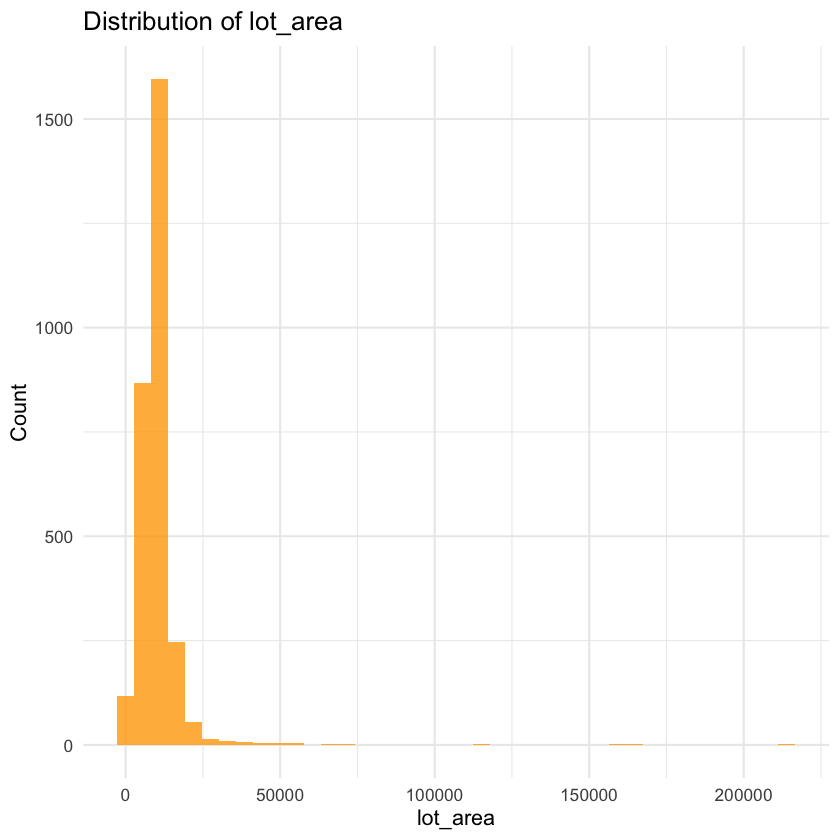

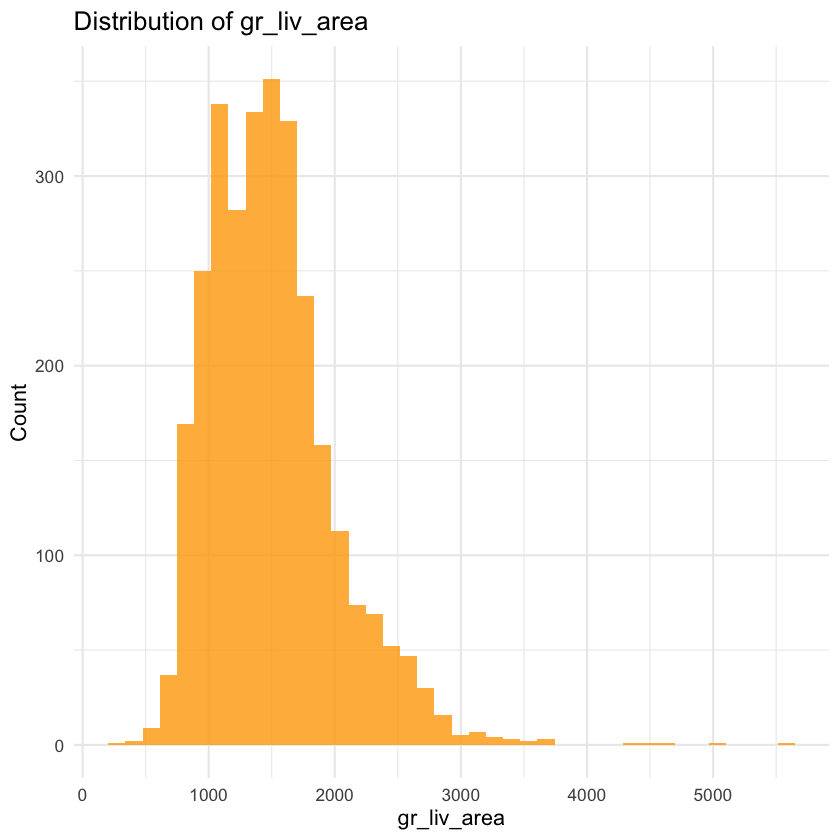

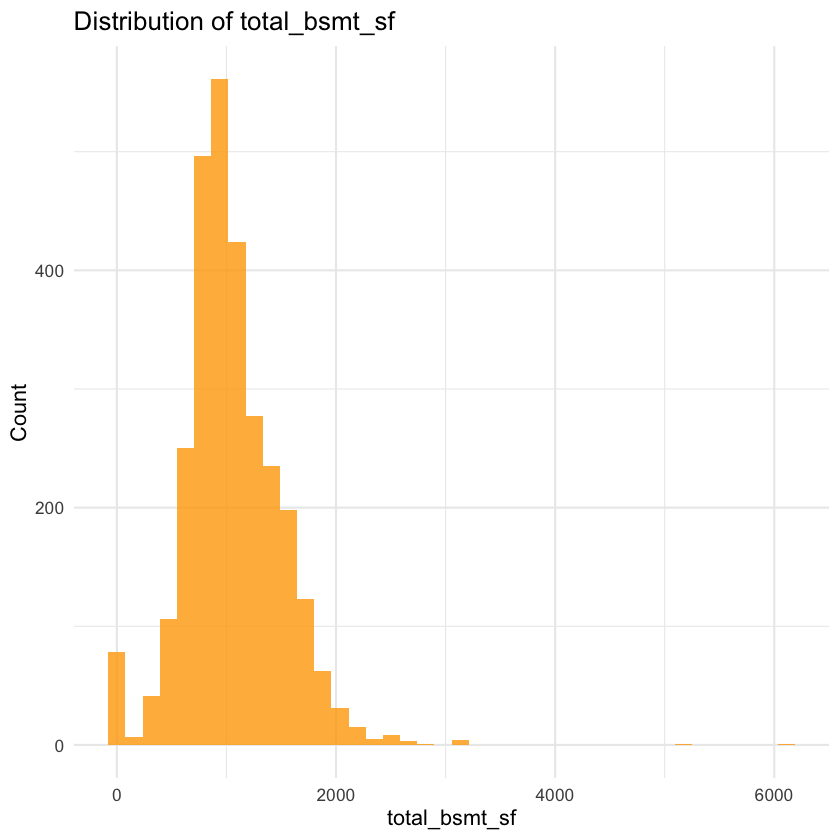

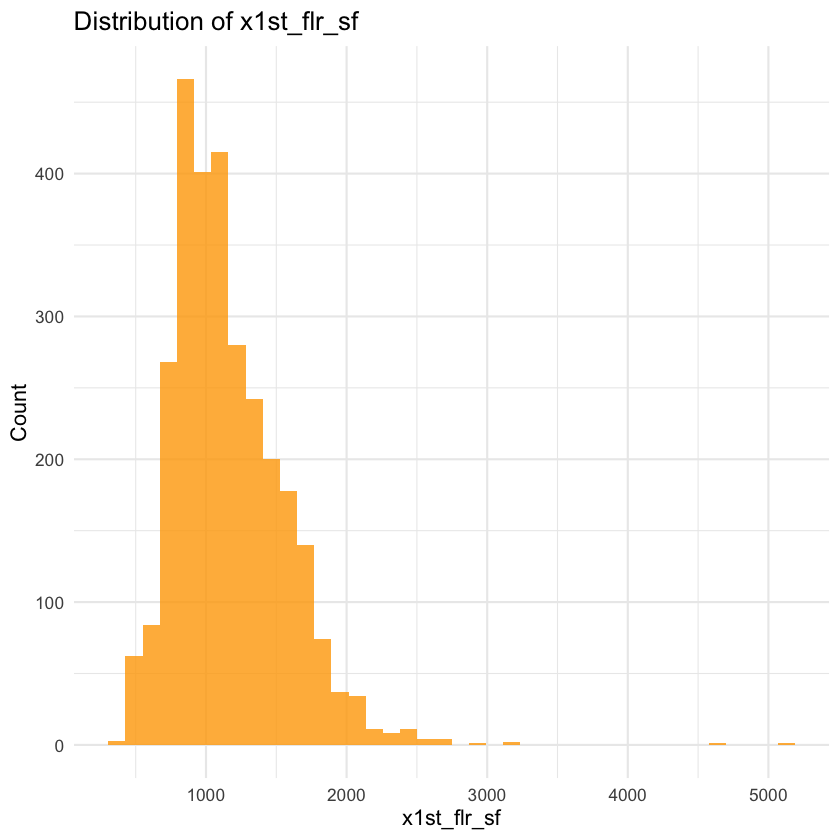

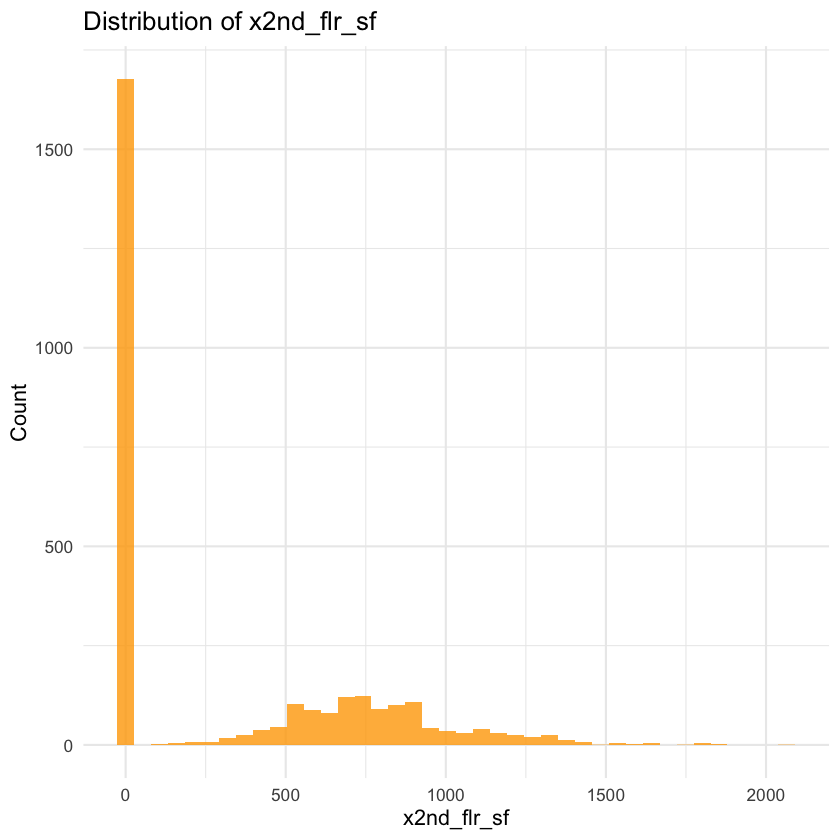

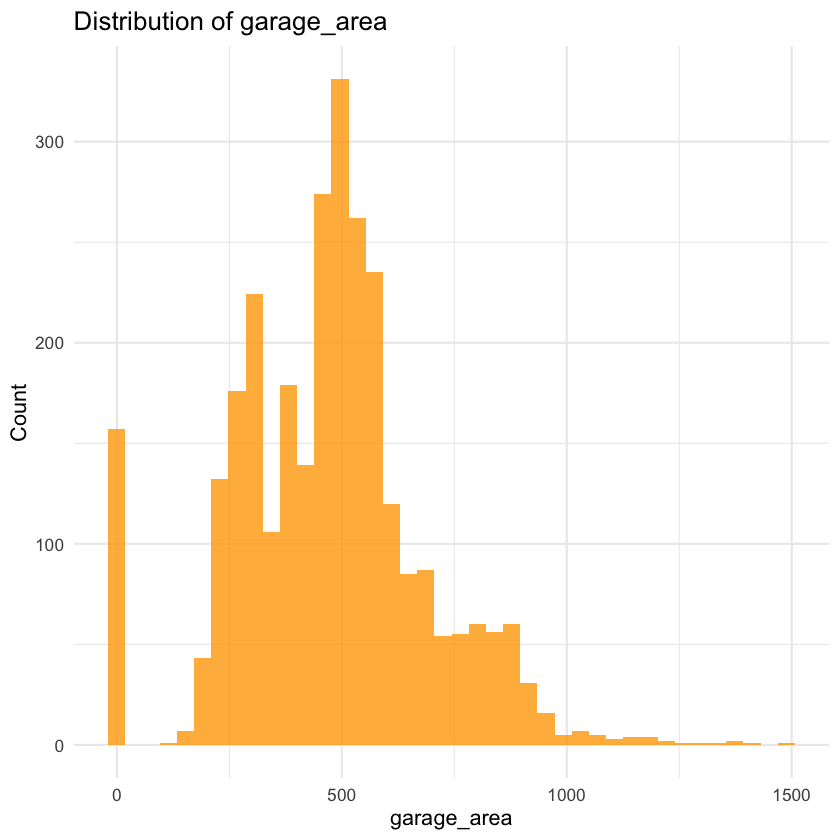

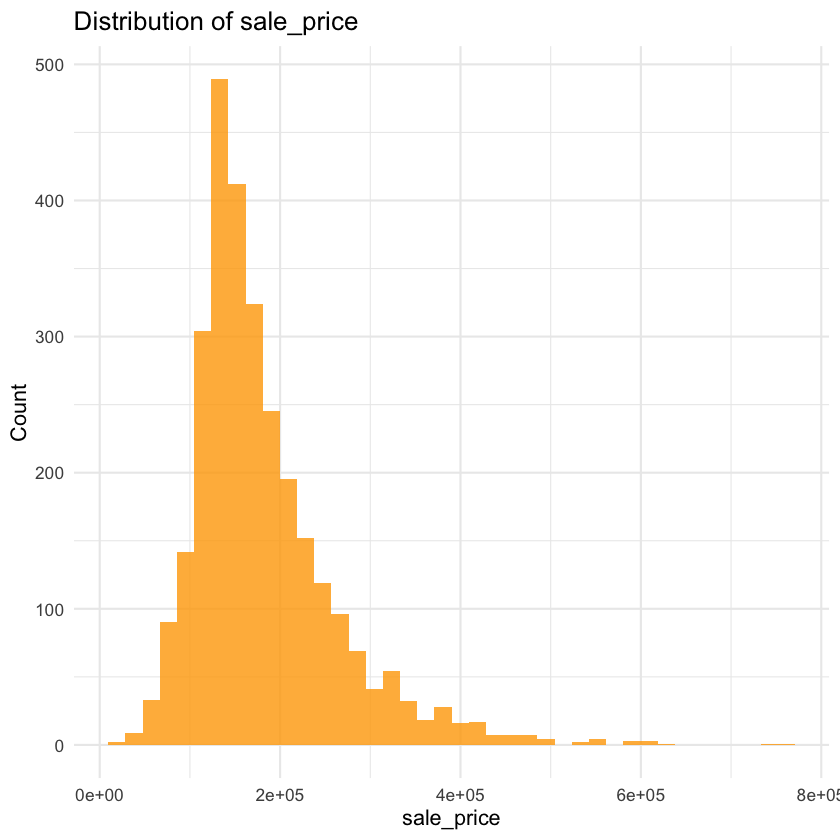

In [15]:
for (v in cont_vars) {
  ggplot(ames, aes_string(x = v)) +
    geom_histogram(bins = 40, fill = "#FFA600", alpha = 0.8) +
    labs(title = paste("Distribution of", v),
         x = v,
         y = "Count") +
    theme_minimal(base_size = 13) -> p
  print(p)
}


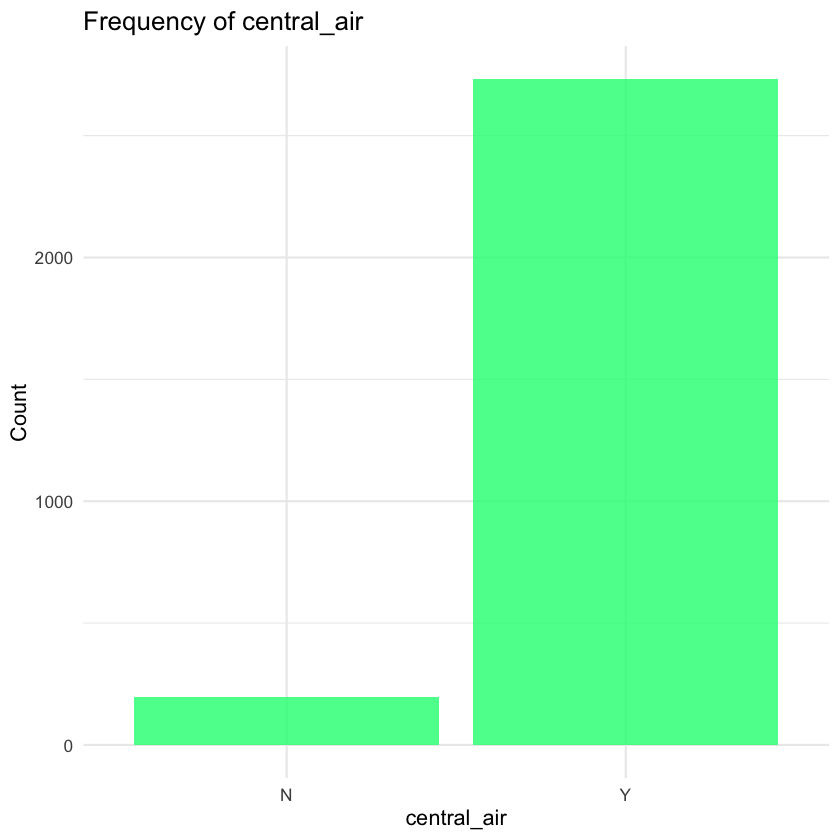

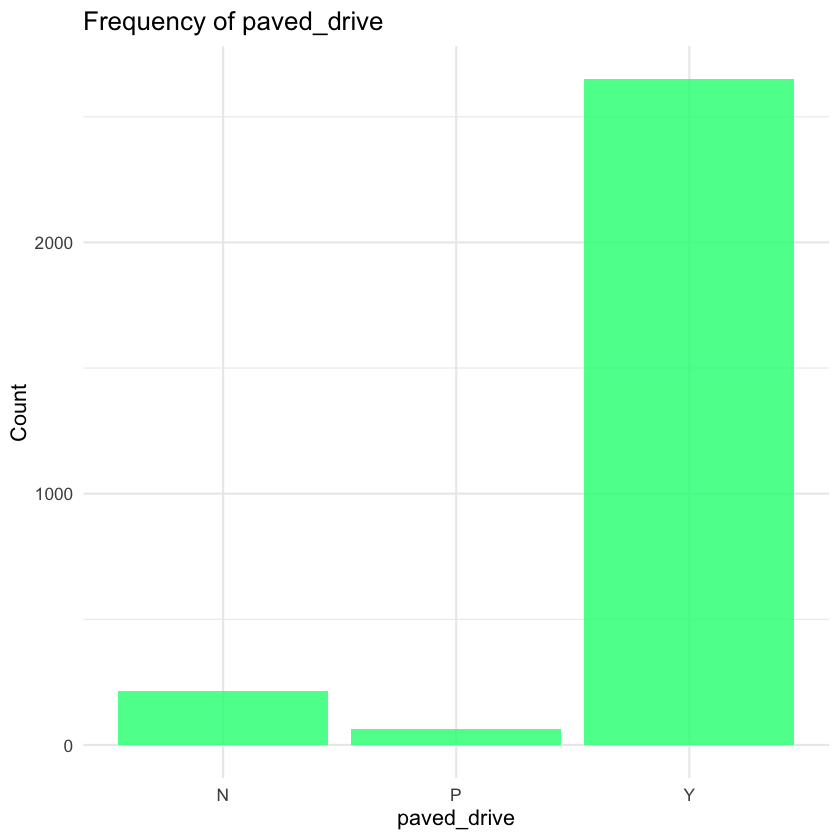

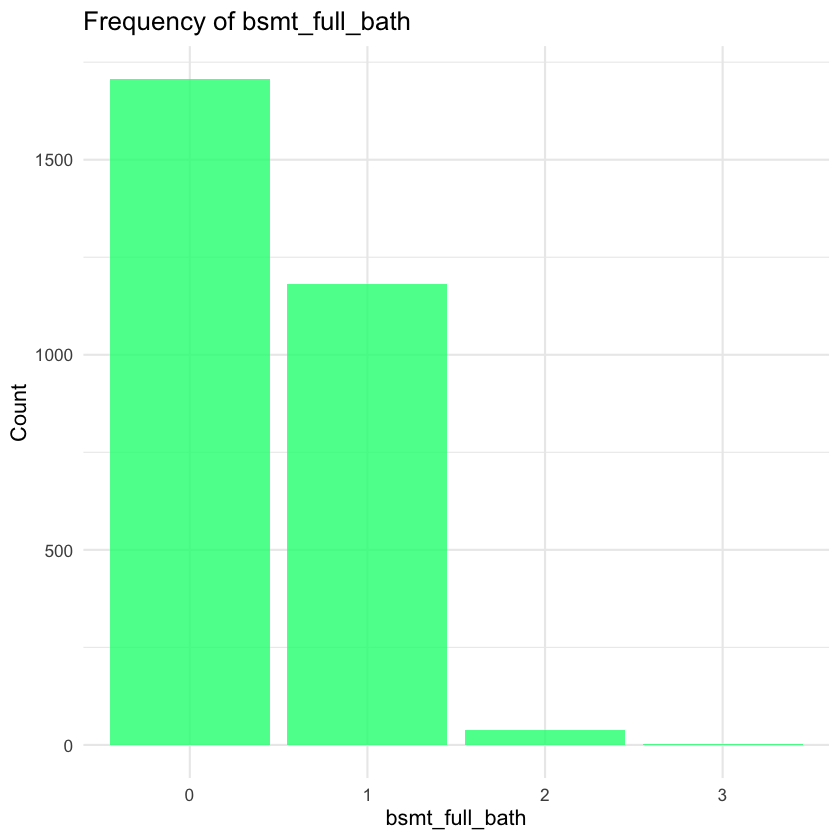

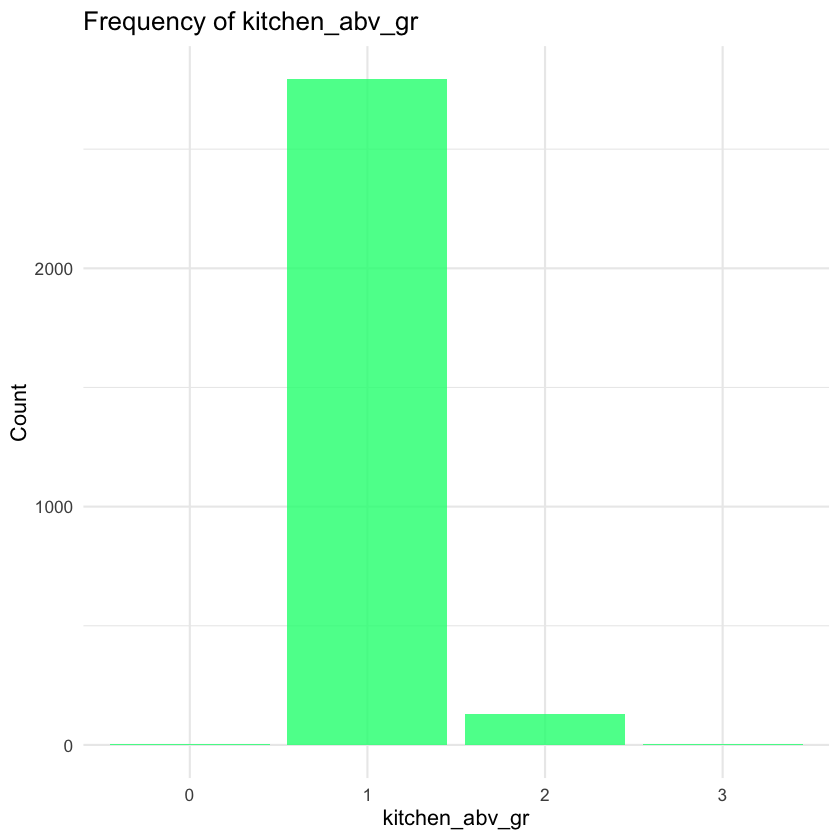

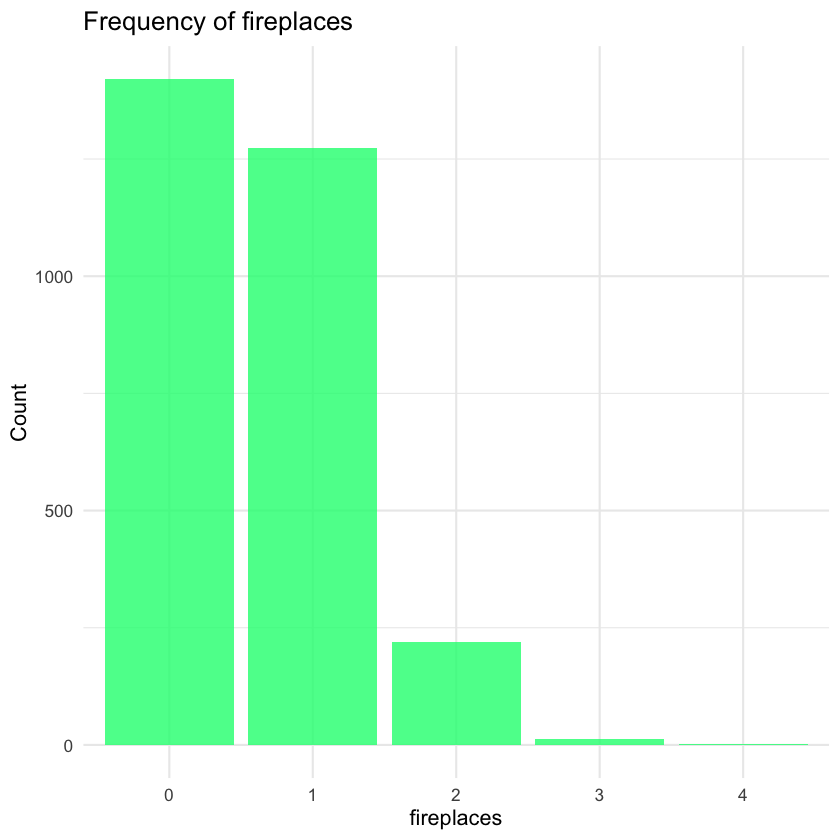

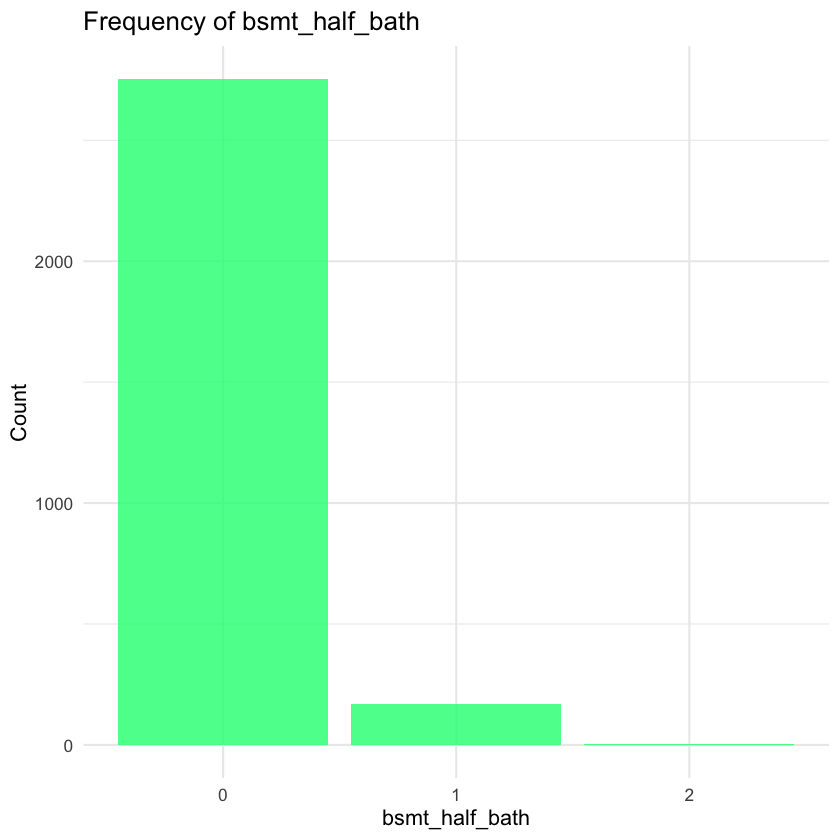

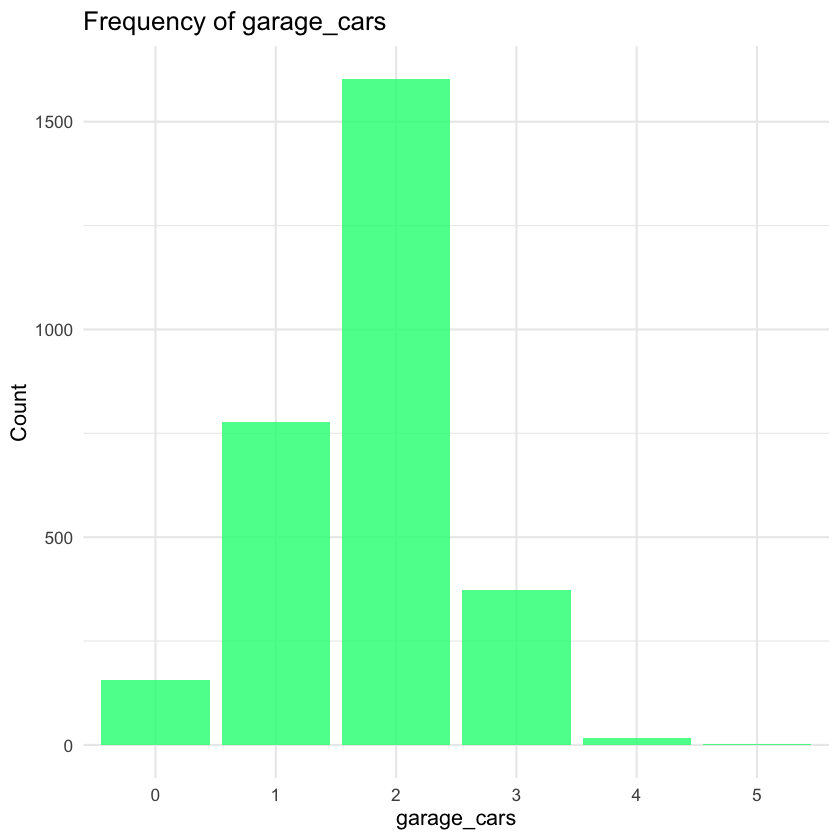

In [16]:
for (v in disc_vars) {
  ggplot(ames, aes_string(x = v)) +
    geom_bar(fill = "#00ff7f", alpha = 0.8) +
    labs(title = paste("Frequency of", v),
         x = v,
         y = "Count") +
    theme_minimal(base_size = 13) -> p
  print(p)
}


Podzielilimsy dane na dwie grupy tj:
- `disc_vars` cechy dyskretne
- `cont_vars` cechy ciagle

Nastpenie przy uzyciu petli `for` idziemy przez kazda ceche i wyswietlamy dla niej wykres, taki rozklad zmiennej.  
  
Tytuly sa w jezyku angielskim by uniknac problemow z wyswietlaniem nazwy wykresu.  
  


### Podsumowanie

Podsumujmy sobei co zrobilismy do tej pory,
- zaimportwoalismy najwazneisjze biblioteki ualtwaijace zycie i prace z danymi czy z wizualizacja danych,
- wczytalismy sb zbior, przejrzelismy go sobie
- wyrbalismye 14 cech tak jak w poprzednich projektach
- zmienilismy typ danych na `factor`
- sprawdzilismy braki i je usunelismy
- zwizualizowalismy kazde ceche z ktora bedziemy pracowac

## CZESC DRUGA

W tej czesci zajmiemy sie jzu wlasciwym budowaniem modelu regresji wielorakiej.

### Instalacja biliotek

Wykorzytsane bilbioteki:
- `e1071` do badania skosnosci

In [28]:
install.packages("e1071")
library(e1071)

install.packages("corrplot")
library(corrplot)

install.packages("car")
library(car)



Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages

Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


instalowanie dodatkowych zalezno'sci 'rbibutils', 'cowplot', 'Deriv', 'microbenchmark', 'Rdpack', 'numDeriv', 'doBy', 'minqa', 'nloptr', 'reformulas', 'Rcpp', 'RcppEigen', 'carData', 'abind', 'Formula', 'pbkrtest', 'lme4'





Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


Ladowanie wymaganego pakietu: carData


Dolaczanie pakietu: 'car'


Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    recode


Nastepujacy obiekt zostal zakryty z 'package:purrr':

    some




In [31]:
install.packages("lmtest")
install.packages("ggplot2")
install.packages("car")
library(car)
library(lmtest)
library(ggplot2)

instalowanie dodatkowych zalezno'sci 'zoo'





Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages

Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages

Pobrane pakiety binarne sa w
	/var/folders/yt/7ptvhg8x3pj99thz7twr6d340000gn/T//RtmpkITVBc/downloaded_packages


Ladowanie wymaganego pakietu: zoo


Dolaczanie pakietu: 'zoo'


Nastepujace obiekty zostaly zakryte z 'package:base':

    as.Date, as.Date.numeric




### Log-Transformacja *SalePrice*

In [18]:
ames <- ames |> mutate(log_sale_price = log1p(sale_price))

Dodajemy zmienna `log_sale_price` w celu zbadania czy zachowa sie lepiej, czy nada sie lepiej do regresji wielorakiej niz `SalePice`.

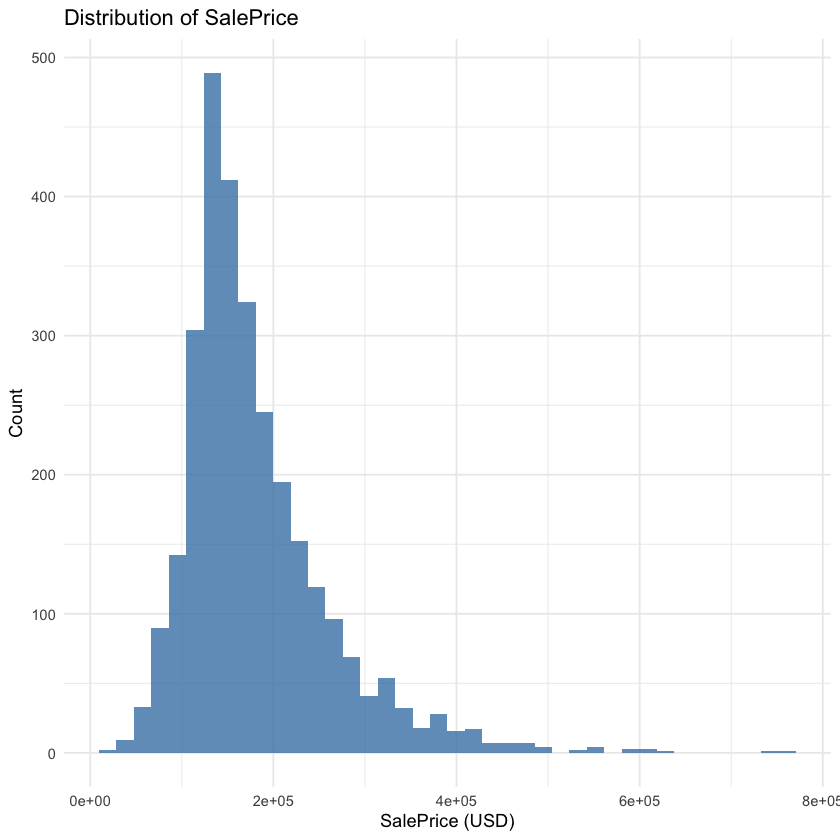

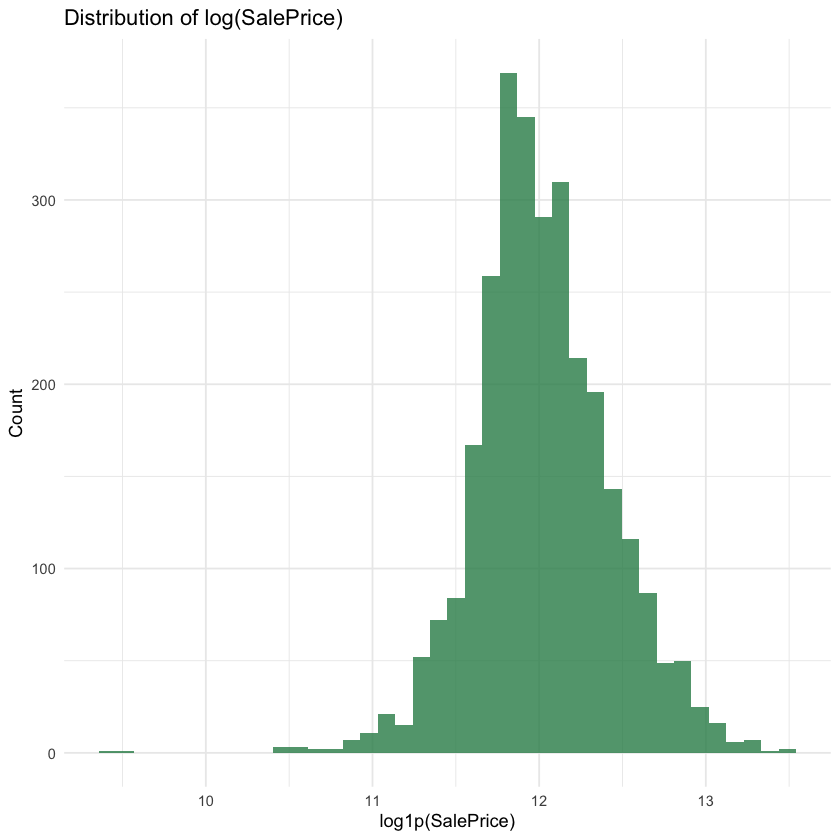

In [19]:
p1 <- ggplot(ames, aes(x = sale_price)) +
        geom_histogram(bins = 40, fill = "steelblue", alpha = 0.8) +
        labs(title = "Distribution of SalePrice", x = "SalePrice (USD)", y = "Count") +
        theme_minimal()

p2 <- ggplot(ames, aes(x = log_sale_price)) +
        geom_histogram(bins = 40, fill = "seagreen", alpha = 0.8) +
        labs(title = "Distribution of log(SalePrice)", x = "log1p(SalePrice)", y = "Count") +
        theme_minimal()

print(p1)
print(p2)

Narysowalimy dwa wykresy, dokaldniej rzecz ujmujac histogramy.  
Histogram dla SalePrice (niebieski) oraz dla log(SalePrice) (zielony).  
  
> **SalePrice** ma dlugi prawy ogon, gdy **log(SalePrice)** jest bardziej skupione wokol sredniej.

In [20]:
skew_raw  <- skewness(ames$sale_price)
skew_log  <- skewness(ames$log_sale_price)

In [21]:
cat("Skewness of SalePrice        :", round(skew_raw,  2), "\n")
cat("Skewness of log(SalePrice)   :", round(skew_log, 2), "\n")

Skewness of SalePrice        : 1.74 


Skewness of log(SalePrice)   : -0.01 


Nastepnie badamy skosnosc obu cech.  
I dochodzimy do konkluzji, ze...  
Generalanie do  przeprwoadzenia regresji wielorakiej lepiej nadaje sie log(SalePrice) chociazby dlatego, ze jej skosnosc jest na poziomie ***-0.01*** co jest znacznie lepsze niz ***1.74***, w przypadku regresji wielorakiej ma znaczenie (o tym troche pozniej).  
  
Proces `log-transformacji` tak jakby sciska te duze wartosci i rozciaga male, to dosyc kolokwialnie powiedzianie, ale wydaje mi sie ze dobrze to oddaje sedno sprawy.
- rozklad w rezultacie zbliza sie do symetrii (skosnosc -> 0)
- zniakaj ogony (odstajace reszty)
  
Warto tez dodac ze do `homoskedatycznosci` tez lepiej nada sie wlasnie zlogotransformowana wartosc SalePrice.  

> Wybieramy ***log(SalePrice)*** do naszej regresji wielorakiej!


### Regresja wieloraka

In [22]:
ames_model <- ames |> 
  select(-sale_price) 

Usuniecie cechy `sale_price`, poniewaz zdecydowalismy sie na `log(sale_price)`.

**Regresja wieloraka** *(ang. multiple linear regression)* rozszerza klasyczną regresję liniową o wiele zmiennych objaśniających.    
Jej celem jest oszacowanie, jak jednoczesny wpływ kilku niezależnych zmiennych ***x1, x2, x3*** przekłada się na średnią wartość zmiennej zależnej ***y***.

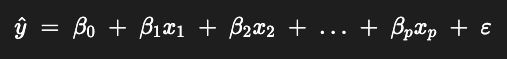

`β0` – wyraz wolny  
`βi` – nachylenie odpowiadające zmiennej 𝑥𝑖  
`ε` – składnik losowy (błąd)

zamaist wzoru takeigo jak powyzej, mzoemy zapisac w psotaci macierzowej.

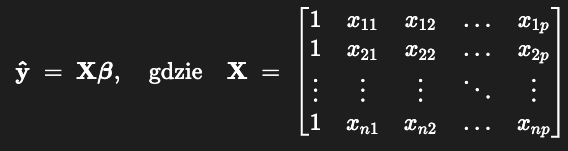

Do najwazniejszysz zalozen modelu:
- liniowosc
- obserwacje sa niezalezne
- homoskedastycznosc
- brak wielokolinearosci (zmiennee objasniajace nie sa silnie ze soba powiazane)
- normalnosc reszt

### Macierz korelacji

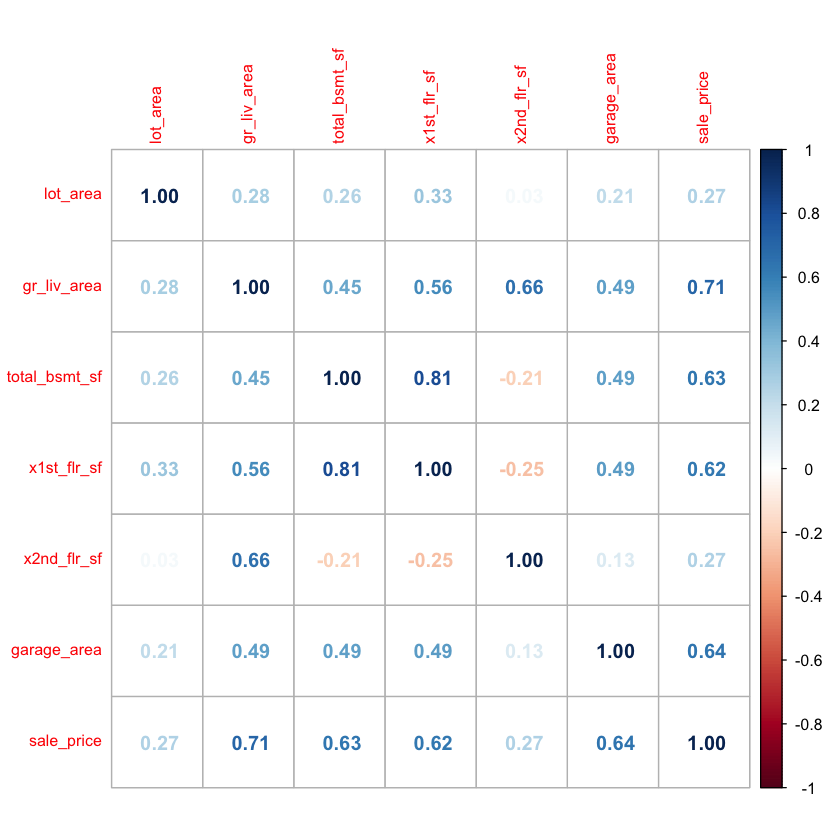

In [27]:
corr_mat <- cor(ames[ , cont_vars])
corrplot(corr_mat, method = "number", tl.cex = 0.8)

Otrzymalismy taki wykres, taka macierz z liczbami...  
Jest to `macierz korelacji` *(ang. heat map)* dla naszych siedmiu cech ciaglych.  
Kazda komorka zawiera ***wspolczynnik Pearsona*** (od -1 do 1).
Wartosci pol przechodza wlasnie od -1 do 1, od niebieskiego do czerwonego.  
Odcienie kolorow informuja jak bardzo dane sa skorelowane.  
  
Cel tej macierzy korelacji jest taki, ze chcemy sprawdzic jak bardzo dane sa ze soba zwiazane.  
Co mogloby wywolac wielokolinearnosci w regresji, czego bysmy nie chcieli.

Przyglądajac sie heatmapie mozemy wysnuc kilka wnioskow:
- `total_bsmt_sf` & `x1st_flr_sf` sa silnie skorelowane na poziomie r = 0.81
- `gr_liv_area` & `x2nd_flr_sf` gdzie r = 066



> wieksza piwnica zazwyczaj idzie w parze z wiekszym  
  
> domy z duzym II pietrem maja ogolnie wieksza powierzchnie

Ogólnie to te korealnosci miedzy cechami nie sa duze poza malymi wyjatkami.  
Uwazamy ze dalsza analiza, oblcizanie statystyk powinny byc zadowalajace.  

### VIF & GVIF

`VIF` *(Variance Inflation Factor)* mierzy ile razy rosnie wariancja **Bi** z powodu współliniowości z innymi zmiennymi.  
- `VIF = 1` --> brak kolinearnosci
- `5 ≤ VIF < 10` --> sredni problem
- `VIF ≥ 10` --> wysoka kolinearnosc
> stosowany do szybkiej diagnsotyki kolinearnosci dla kazdej kolumny

`GVIF` *(Generalized Variance Inflation Factor)* potrzebna miara gdy jest wiecej zmiennych niz 1 paramtert w modelu.  
> taki VIF tylko rozserzony

___
Oba te narzedzia pozwalaja na wychwycenie problemow z kolinearnoscia.  

In [29]:
model_tmp <- lm(log_sale_price ~ ., data = ames |> select(-sale_price))
vif(model_tmp)

,GVIF,Df,GVIF^(1/(2*Df))
central_air,1.294578,1,1.137795
paved_drive,1.377069,2,1.083275
bsmt_full_bath,1.509091,3,1.070991
kitchen_abv_gr,2.417805,3,1.158520
fireplaces,2.557950,4,1.124570
bsmt_half_bath,2.564025,2,1.265408
garage_cars,7.754003,5,1.227305
lot_area,1.237226,1,1.112307
gr_liv_area,119.775190,1,10.944185
total_bsmt_sf,3.405143,1,1.845303


Opiszmy sobie co widzimy powyzej.  
- Nazwa cechy
- `GVIF` - uogolniony VIF
- `Df` czyli liczba stopni swobody zmiennej
- `GVIF^(1/(2*Df))` orekta GVIF dla porównywalnosci zmiennych o roznych liczbach stopni swobody

Obserwacje:
- `gr_liv_area` - **GVIF = 119** - baaardzo silnie skorelowana
- `x2nd_flr_sf` - **GVIF = 88** - silna wspołliniowosc
- `x1st_flr_sf` - **GVIF = 76** - tez silna wspołliniowosc
- `garage_cars` - **GVIF = 7.75** - w granicach tolerancji

Wnioski:
- `gr_liv_area`, `x1st_flr_sf`, `x2nd_flr_sf` sa silnie ze soba skorelowane,  
nie ma co sie dziwic, gdyz opisuja prawie ze to samo,  
powierzchnia calkowita, parter, pietro musza byc ze soba powiazane.  
- `garage_cars` i `garage_area` tez sa ze soba powiazane

Teraz tak co dalej:
- wystarczy zatrzymac jedna zmienna opisujaca mieszkanie ze zmiennych `gr_liv_area`, `x1st_flr_sf`, `x2nd_flr_sf` bo sa silnie skorelowane ze soba
- `garage_cars` i `garage_area` sa skorelowane tez wiec wysatrczy zostawic jedna
- inne zmienne mozna zostawic

In [30]:
ames_reduced <- ames_model |>
  select(-x1st_flr_sf, -x2nd_flr_sf, -garage_cars)
model1 <- lm(log_sale_price ~ ., data = ames_reduced)
vif(model1)

,GVIF,Df,GVIF^(1/(2*Df))
central_air,1.268084,1,1.126093
paved_drive,1.277660,2,1.063173
bsmt_full_bath,1.387031,3,1.056042
kitchen_abv_gr,2.249705,3,1.144689
fireplaces,2.406833,4,1.116043
bsmt_half_bath,2.519607,2,1.259892
lot_area,1.207123,1,1.098691
gr_liv_area,1.781201,1,1.334616
total_bsmt_sf,1.628621,1,1.276175
garage_area,1.630543,1,1.276927


W tym kroku usunelismy zmienne `x1st_flr_sf`, `x2nd_flr_sf` i `garage_cars`.  
Ponownie wywolalismyw wykres i widzimy ze faktycznie skorelowanie sie poprawilo, w sensie ze jest na dobrym poziomie nie przekraczajacym granicy tolerancji.

### Reszty

#### QQ-plot

**QQ-plot** *(Quantile-Quantile plot)*  
Wykres porównujący *empiryczne kwantyle* naszych reszt z *teoretycznymi kwantylami* rozkładu normalnego. Jeśli reszty są w przybliżeniu normalne, punkty powinny układać się blisko linii prostej 45°.   
  
Rysujemy ten wykres aby sprawdzić normalnośći rozkłądu błedow.

Warning message in matrix(yhat, n, reps):
"dlugo's'c danych [2927] nie jest pod-wielokrotno'scia lub wielokrotno'scia liczby wierszy [2926]"


ERROR: Error in model.frame.default(formula = Y ~ X - 1, drop.unused.levels = TRUE): dlugo'sci zmiennych r'oznia sie (znaleziono dla 'X')


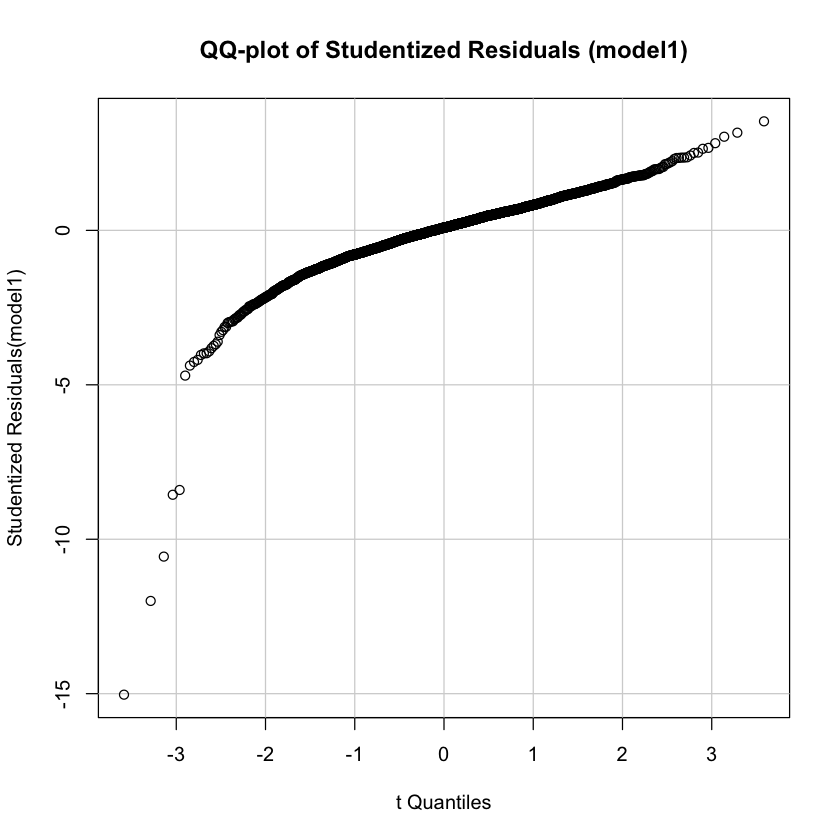

In [38]:
qqPlot(model1, main = "QQ-plot of Studentized Residuals (model1)")

Obserwacje:
- od kwantyla -1 do +2 punkty leza na prostej
- kwantyle do -2 widac lewy ogon, punkty spadaja z linii
- kwantyle od +3 widac lekkei odchylenie, mniejsze niz w lewym ogonie

Wnioski:
- dla wiekszosci obserwacji rozklad jest bliski normlanemu
- sa obserwacje ktore nie pasuja do rozkladu normalnego

#### Residuals vs Fitted

Wykres stosuje sie w celu:
- sprawdzenia liniwoosci
- sprawdzenia homoskedastyczności
- sprawdzenie outlinerow  
  
Budowa wykresu
- `Os x` *(fitted values)* prognozowane wartoci czyli u nas `log(saleprice)`
- `Os y` *(residuals)* roznica w predykcji a faktyczna wartoscia.
    - Jeśli wariancja reszt jest stała (homoskedastyczna) punkty powinny tworzyć losową chmurę bez wzoru.
- `Czerwona linia`* (loess smooth)* powinna przebiegać poziomo przy 0.

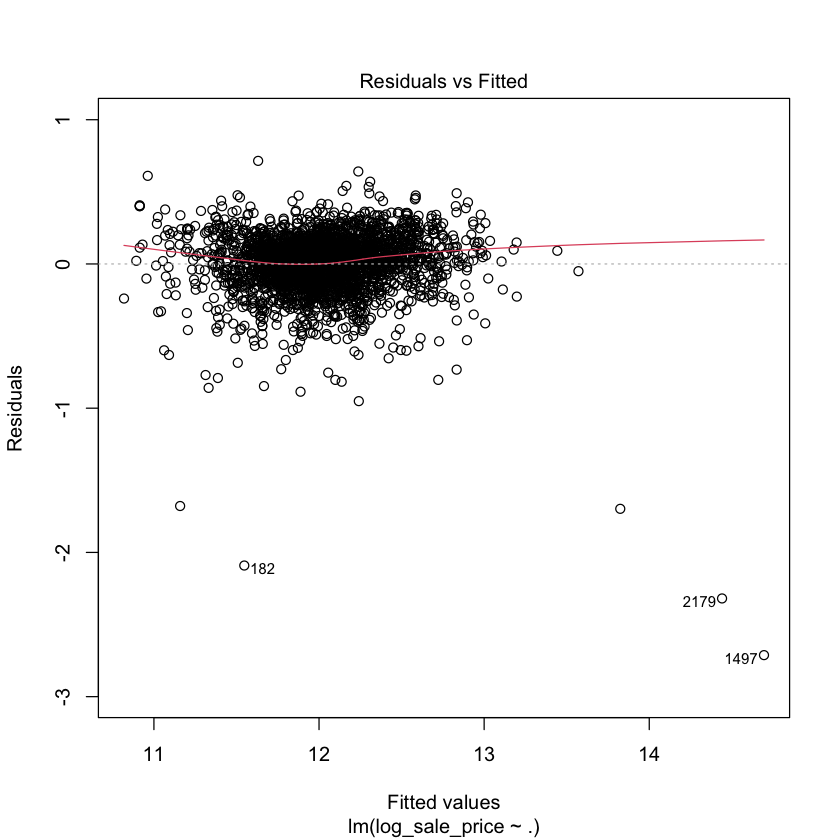

In [33]:
plot(model1, which = 1) 

Obserwacje:
- brak lejka
- Punkty nie rozszerzają się ani nie zwężają wyraźnie wraz z rosnącymi fitted
- obserwacje oznaczone 182, 2179 i 1497 mają reszty ujemne,co może oznaczać domy, których cena była znacznie niższa od przewidywanej przez model 
  
  
Wnioski:
- wariancja reszt wyglada na stała  

> Założenie homoskedastyczności wizualnie jest spełnione

#### Scale-Location plot

Warning message:
"brak wykre'slalnych obserwacji z jednej transmisji:
  2496"


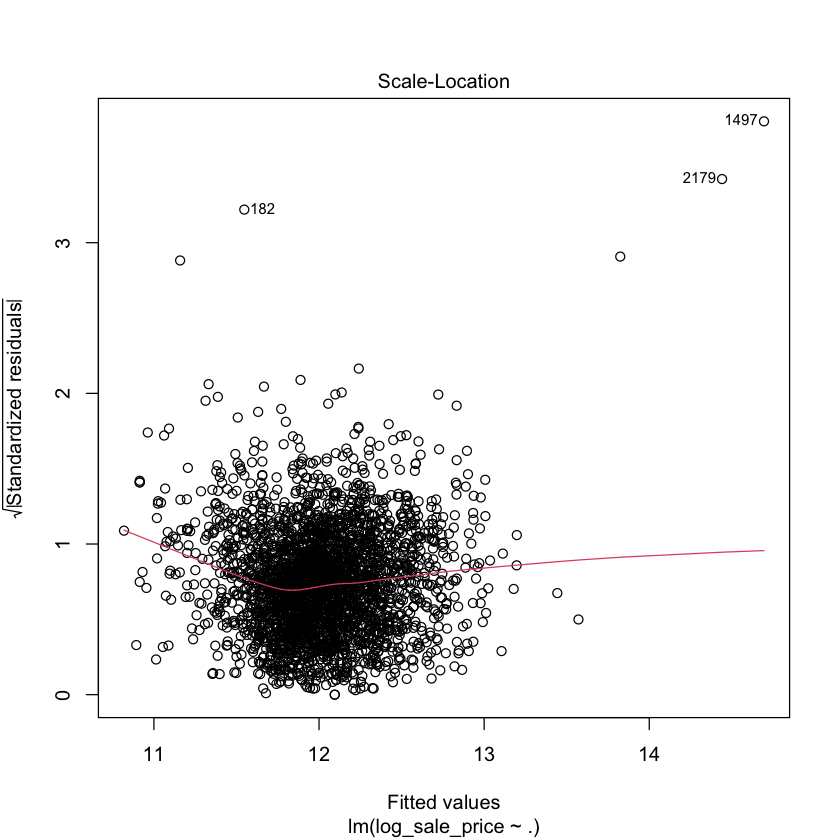

In [34]:
plot(model1, which = 3)

Obserwacje: 
- niewielka dolina po lewej
- lekki wzrost po prawej stronie, po dolinie
- brak klasycznego lejka
    -  nie rozszerzają się ani dramatycznie nie zwężają

Wnioski:
- Homoskedastyczność nie jest poważnie naruszona
- takie niewielkie odchylenia można uznać za akceptowalne przy tak dużej próbie
- wariancja reszt dla najtańszych domów jest trochę wyższa, a od średnich cen w górę stopniowo rośnie, ale zmiana jest łagodna


#### Shappiro Test

`Statystyka W` mierzy, jak dobrze uporządkowane wartości pasują do prostoliniowego układu oczekiwanego przy normalności.  
`Statystyka p-value` to miara zgodnosci danych z normalnoscia.  
  
___
Jesli liczba obserwacji `< 30` to test nie wychwyci subtelnych odchyleń (może dać wysokie p-value mimo nienormalności).  
Jesli liczba obserwacji `> 5000` to test cechuje sie wysoka czuloscia, nawet drobne różnice dadzą bardzo małe p-value.

In [35]:
shapiro_test <- shapiro.test(rstandard(model1))
shapiro_test


	Shapiro-Wilk normality test

data:  rstandard(model1)
W = 0.86631, p-value < 2.2e-16


`W = 0.866`  
Im blizej 1, tym bardziej rozklad przypomina normlany.  
  
`p-value < 2.2e-16`  
Niskie `p-value` to silny dowod aby odrzucic hipoteze o normalnsoci rozkaldu.

Jednakze nalezy ten **test Shappiro Wilka** zestawic z *QQ plotem*, gdyz sam test bez analizy graficznej nie daje pelni informacji i podstaw do wyciagania wnioskow.  
  
Jak sie okazuje, `QQ-plot` pokazał, że środek rozkładu jest OK, a problem leży w kilku skrajnych obserwacjach (lewy ogon).  
Jak juz wspominalem `Shapiro-Wilk` jest bardzo czuły przy dużych próbach *(mamy prawie 3000 obserwacji)* – nawet drobne odchylenia w ogonie dają ekstremalnie małe p-value.

> test sygnalizuje, że reszty nie są idealnie normalne, ale wizualnie większość punktów spełnia założenie.

#### Breusch-Pagan test

Ten test wykrywa `heteroskedastyczność`, czyli odpowiada na pytanie czy wariancja reszt zależy od wartości przewidywanych lub od samych zmiennych objaśniających.

In [36]:
bp_test <- bptest(model1)
bp_test


	studentized Breusch-Pagan test

data:  model1
BP = 394.39, df = 19, p-value < 2.2e-16


Obserwacje:
- Ogromna wartość statystyki i p-value praktycznie 0

Wnioski:
- test przemawia za tym, ze w modelu wystepuje heteroskedastyczność
- rozrzut błędów zmienia się wraz z poziomem predyktorów.

#### Durbin-Watson test

`Durbin-Watson test` wykrywa autokorelację ***I-go rzędu w resztach regresji liniowej***, czyli czy błąd w obserwacji *i* zależy od błędu w obserwacji *i – 1*.

In [37]:
dw_test <- dwtest(model1)
dw_test


	Durbin-Watson test

data:  model1
DW = 1.5194, p-value < 2.2e-16
alternative hypothesis: true autocorrelation is greater than 0


Obserwacje: 
- `DW ~ 1,5` sugeruje dodatnią autokorelację reszt
    - sąsiednie obserwacje mają podobne znaki i wartości błędu.
- `p-value ≈ 0` zdecydowanie odrzucamy hipoteze o braku autokorelacji.  
  
Wnioski:
- Mniejsze od rzeczywistych odchylenia standardowe
- Prognozy mogą być mniej wiarygodne dla grup obserwacji o podobnych cechach